In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
torch.manual_seed(42)

In [3]:
df = pd.read_csv("fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


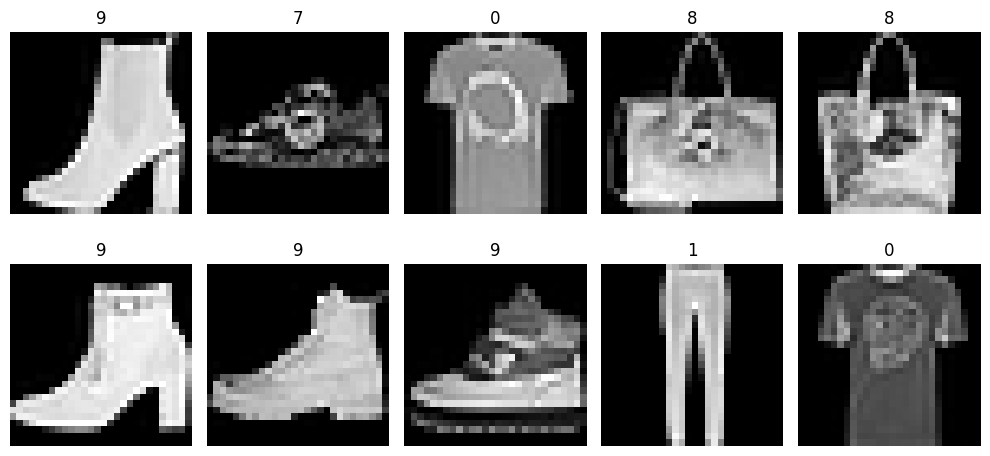

In [4]:
# visualizing image
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    label = df.iloc[i, 0]
    image = df.iloc[i, 1:].values.reshape(28, 28)

    ax.imshow(image, cmap="gray")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [7]:
X_train = X_train/255.0
X_test = X_test/255.0

In [18]:
class CustomDataset(Dataset):

    def __init__(self,features,labels):
        super().__init__()
        self.features = torch.tensor(features,dtype=torch.float32)
        self.labels = torch.tensor(labels,dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index],self.labels[index]

In [19]:
train_dataset = CustomDataset(X_train,y_train)

In [20]:
len(train_dataset)

4800

In [21]:
test_dataset = CustomDataset(X_test,y_test)

In [22]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [23]:
class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
         )

    def forward(self,x):
        return self.model(x)

In [24]:
epochs = 100
learning_rate = 0.1

In [25]:
model = MyNN(X_train.shape[1])

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(),lr=learning_rate)

In [26]:
for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_feature,batch_labels in train_loader:
        #forward pass
        outputs = model(batch_feature)
        # loss calc
        loss = criterion(outputs,batch_labels)

        # back pass
        optimizer.zero_grad()
        loss.backward()

        # update grad
        optimizer.step()

        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss/len(train_loader)
    print(f"Epoch:{epoch+1}, Loss:{avg_loss}")
        

Epoch:1, Loss:1.366908950805664
Epoch:2, Loss:0.7868862213691076
Epoch:3, Loss:0.6612437709172567
Epoch:4, Loss:0.5921929277976354
Epoch:5, Loss:0.5361840746800105
Epoch:6, Loss:0.5050876119732857
Epoch:7, Loss:0.48812635471423466
Epoch:8, Loss:0.4525501771767934
Epoch:9, Loss:0.4279777346054713
Epoch:10, Loss:0.41536084686716396
Epoch:11, Loss:0.3844427560766538
Epoch:12, Loss:0.3691315809885661
Epoch:13, Loss:0.36443998167912167
Epoch:14, Loss:0.3432158373792966
Epoch:15, Loss:0.31625149071216585
Epoch:16, Loss:0.31102749223510423
Epoch:17, Loss:0.30239750077327093
Epoch:18, Loss:0.29915920267502466
Epoch:19, Loss:0.27624933488667014
Epoch:20, Loss:0.27106629172960917
Epoch:21, Loss:0.2613050943861405
Epoch:22, Loss:0.2524890288213889
Epoch:23, Loss:0.24772734329104423
Epoch:24, Loss:0.2351538403580586
Epoch:25, Loss:0.23352973207831382
Epoch:26, Loss:0.23249971481661003
Epoch:27, Loss:0.2239253746966521
Epoch:28, Loss:0.21364408870538076
Epoch:29, Loss:0.21787989748020967
Epoch:30, 